In [1]:
# Importaciones estándar
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.metrics import geometric_mean_score
import warnings

warnings.filterwarnings('ignore')

# Añadir la raíz del proyecto al path para importar el paquete src
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Importar nuestras herramientas topológicas modulares
from src import compute_complexity_metrics, topological_ratio_optimizer

print("Entorno listo. Módulos topológicos cargados correctamente.")

Entorno listo. Módulos topológicos cargados correctamente.


In [4]:
# Carga de datos
try:
    df = pd.read_csv('~/Proyectos/HARS/Datasets/yeast1.csv')
except FileNotFoundError:
    df = pd.read_csv('yeast1.csv')

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# División estratificada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

clases, conteos = np.unique(y_train, return_counts=True)
clase_min = clases[np.argmin(conteos)]
ratio_original = conteos[np.argmin(conteos)] / conteos[np.argmax(conteos)]

print(f"Dimensiones de entrenamiento: {X_train.shape}")
print(f"Ratio original de desbalance: {ratio_original:.3f}")

Dimensiones de entrenamiento: (1038, 9)
Ratio original de desbalance: 0.407


In [5]:
def evaluar_rendimiento_predictivo(X_tr, y_tr):
    """Entrena un Random Forest y devuelve el G-mean en el conjunto de prueba intacto."""
    rf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_test)
    return geometric_mean_score(y_test, y_pred)

print("Iniciando evaluación topológica y predictiva...")
ratios_a_probar = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
resultados = []

# 1. Evaluar el estado original (Baseline)
metricas_orig = compute_complexity_metrics(X_train, y_train, target_class=clase_min)
gmean_orig = evaluar_rendimiento_predictivo(X_train, y_train)

resultados.append({
    'Ratio SMOTE': round(ratio_original, 3),
    'N3 (Solapamiento)': metricas_orig['N3'],
    'L2 (No-Linealidad)': metricas_orig['L2'],
    'dwCM9 (Vulnerabilidad)': metricas_orig['dwCM9'],
    'G-mean (Rendimiento Test)': gmean_orig
})

# 2. Barrido de Ratios con SMOTE
for r in ratios_a_probar:
    smote = SMOTE(sampling_strategy=r, random_state=42)
    X_res, y_res = smote.fit_resample(X_train, y_train)
    
    # Llamada limpia al módulo de Barella
    metricas = compute_complexity_metrics(X_res, y_res, target_class=clase_min)
    gmean = evaluar_rendimiento_predictivo(X_res, y_res)
    
    resultados.append({
        'Ratio SMOTE': r,
        'N3 (Solapamiento)': metricas['N3'],
        'L2 (No-Linealidad)': metricas['L2'],
        'dwCM9 (Vulnerabilidad)': metricas['dwCM9'],
        'G-mean (Rendimiento Test)': gmean
    })

# Formatear resultados
df_resultados = pd.DataFrame(resultados).set_index('Ratio SMOTE')
pd.set_option('display.float_format', '{:.4f}'.format)

print("\n=== MATRIZ DE RESULTADOS DEL EXPERIMENTO ===")
display(df_resultados)

Iniciando evaluación topológica y predictiva...

=== MATRIZ DE RESULTADOS DEL EXPERIMENTO ===


,N3 (Solapamiento),L2 (No-Linealidad),dwCM9 (Vulnerabilidad),G-mean (Rendimiento Test)
Ratio SMOTE,,,,
0.4070,0.5067,0.6933,0.5087,0.6821
0.5000,0.3604,0.5881,0.4249,0.6676
0.6000,0.2489,0.5339,0.3624,0.6809
0.7000,0.2016,0.4496,0.3124,0.6720
0.8000,0.1424,0.3814,0.2644,0.7069
0.9000,0.1280,0.3313,0.2238,0.6680
1.0000,0.0908,0.2818,0.2081,0.6780


✔️ Mayor rendimiento empírico en Ratio: 0.8 (G-mean: 0.7069)
❌ Rendimiento con balanceo total (1.0): 1.0 (G-mean: 0.6780)


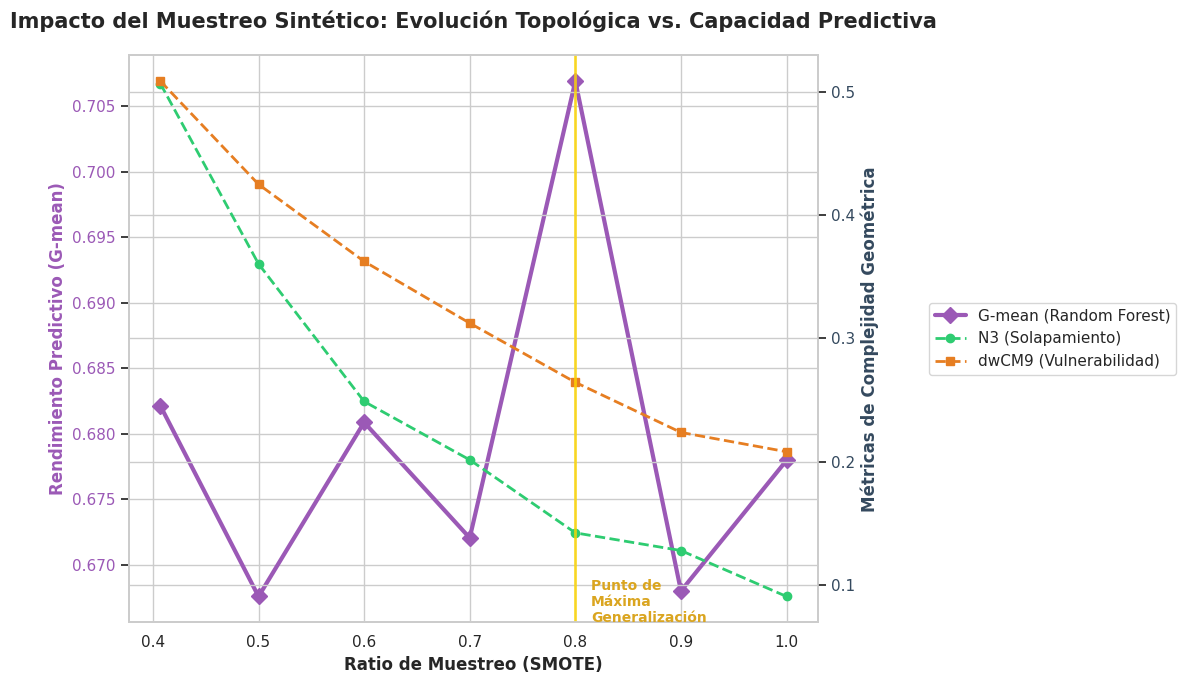

In [6]:
mejor_ratio = df_resultados['G-mean (Rendimiento Test)'].idxmax()
mejor_gmean = df_resultados.loc[mejor_ratio, 'G-mean (Rendimiento Test)']
gmean_completo = df_resultados.loc[1.0, 'G-mean (Rendimiento Test)']

print(f"✔️ Mayor rendimiento empírico en Ratio: {mejor_ratio} (G-mean: {mejor_gmean:.4f})")
print(f"❌ Rendimiento con balanceo total (1.0): 1.0 (G-mean: {gmean_completo:.4f})")

# Visualización con doble eje (Y1: Rendimiento, Y2: Topología)
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 7))

# Eje 1: Rendimiento Predictivo
color_gmean = '#9b59b6'
ax1.set_xlabel('Ratio de Muestreo (SMOTE)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Rendimiento Predictivo (G-mean)', color=color_gmean, fontsize=12, fontweight='bold')
linea1 = ax1.plot(df_resultados.index, df_resultados['G-mean (Rendimiento Test)'], 
                  marker='D', color=color_gmean, linewidth=3, markersize=8, label='G-mean (Random Forest)')
ax1.tick_params(axis='y', labelcolor=color_gmean)

# Eje 2: Métricas Topológicas
ax2 = ax1.twinx()  
color_metrics = '#34495e'
ax2.set_ylabel('Métricas de Complejidad Geométrica', color=color_metrics, fontsize=12, fontweight='bold')
linea2 = ax2.plot(df_resultados.index, df_resultados['N3 (Solapamiento)'], 
                  marker='o', color='#2ecc71', linewidth=2, linestyle='--', label='N3 (Solapamiento)')
linea3 = ax2.plot(df_resultados.index, df_resultados['dwCM9 (Vulnerabilidad)'], 
                  marker='s', color='#e67e22', linewidth=2, linestyle='--', label='dwCM9 (Vulnerabilidad)')
ax2.tick_params(axis='y', labelcolor=color_metrics)

# Unificar leyendas
lineas = linea1 + linea2 + linea3
etiquetas = [l.get_label() for l in lineas]
ax1.legend(lineas, etiquetas, loc='center left', bbox_to_anchor=(1.15, 0.5), fontsize=11, frameon=True)



plt.title('Impacto del Muestreo Sintético: Evolución Topológica vs. Capacidad Predictiva', fontsize=15, fontweight='bold', pad=20)
plt.axvline(x=mejor_ratio, color='gold', linestyle='-', linewidth=2, alpha=0.8)
plt.text(mejor_ratio + 0.015, ax2.get_ylim()[0], 'Punto de\nMáxima\nGeneralización', color='goldenrod', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()